## 1. Import necessary Libraries

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score

## 2. Load the Data

In [4]:
college_data=pd.read_csv("college_list.csv")
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9
...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6


## 3. Data Understanding

In [5]:
college_data.shape

(500, 6)

In [6]:
college_data.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64

In [7]:
college_data.dtypes

College_Name              object
Student_Faculty_Ratio      int64
Annual_Fees_INR            int64
Placement_Percentage       int64
Average_Package_LPA      float64
Infrastructure_Score       int64
dtype: object

In [8]:
college_data.describe()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600
std,6.683283,63928.678815,17.193465,2.917991,2.00486
min,8.000000,30404.000000,40.000000,2.000000,3.00000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000
max,29.000000,249930.000000,99.000000,11.990000,9.00000


## 4. Data Preparation

### 4.1 Remove the unwanted features

In [9]:
college_data.head(2)

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7


In [11]:
X=college_data.drop(labels="College_Name",axis=1)
X.head()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9


### 4.2 Data Transformation - it is a mandatory step for the algorithms which are using the distance

In [12]:
scaled_X=StandardScaler()
scaled_X=scaled_X.fit_transform(X)
scaled_X=pd.DataFrame(scaled_X)
scaled_X.head()

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845


### To check whether the mean=0 and standard deviation is 1 across the features since we used the Standardization technique(StandardScaler())

In [14]:
print("Mean:\n",scaled_X.mean().round(4))
print("Standard Deviation:\n",scaled_X.std().round(4))

Mean:
 0    0.0
1    0.0
2   -0.0
3    0.0
4   -0.0
dtype: float64
Standard Deviation:
 0    1.001
1    1.001
2    1.001
3    1.001
4    1.001
dtype: float64


## 5. Model Building - Build Cluster algorithm

In [17]:
kmeans_cluster=KMeans(n_clusters=3,random_state=12)
kmeans_cluster.fit(scaled_X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,12
,copy_x,True
,algorithm,'lloyd'


In [18]:
kmeans_cluster.cluster_centers_

array([[ 0.80005965, -0.35292454,  0.06058015, -0.06989436,  0.7879027 ],
       [ 0.33899088,  0.07714374,  0.32735611,  0.04780598, -1.0553563 ],
       [-0.9460557 ,  0.21270177, -0.34396936,  0.0127609 ,  0.32235082]])

In [19]:
kmeans_cluster.labels_

array([2, 0, 0, 0, 2, 1, 1, 0, 2, 1, 1, 1, 0, 2, 1, 1, 2, 0, 1, 2, 1, 2,
       2, 0, 1, 1, 2, 0, 0, 0, 0, 1, 1, 2, 2, 1, 1, 0, 2, 1, 1, 1, 1, 0,
       1, 0, 2, 0, 1, 2, 2, 1, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 1, 0, 2, 0,
       1, 1, 2, 0, 2, 1, 0, 0, 1, 2, 1, 0, 0, 2, 1, 2, 0, 1, 1, 1, 1, 2,
       2, 2, 2, 1, 1, 0, 0, 1, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 0, 1, 2, 2,
       0, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0, 1, 2, 2, 2, 0, 2, 2, 1, 0, 0, 0,
       0, 0, 1, 0, 2, 2, 2, 1, 0, 0, 2, 1, 1, 0, 0, 2, 2, 0, 0, 2, 0, 0,
       0, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 2, 2, 2, 1, 2, 0, 0, 1, 2, 2, 1, 2, 2, 2, 0, 2, 0, 2,
       2, 2, 1, 1, 1, 2, 1, 2, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 2, 0, 1,
       1, 1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 1, 0, 1, 1, 2, 0, 1, 0, 0, 2, 2,
       0, 0, 2, 2, 1, 2, 2, 0, 1, 0, 1, 1, 0, 2, 0, 1, 1, 1, 2, 2, 0, 1,
       1, 0, 2, 1, 0, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 0, 1, 1, 1, 2, 2,
       1, 2, 0, 0, 1, 0, 1, 0, 2, 2, 1, 0, 0, 1, 2,

### Clustering is DONE here. Let's put this back to the original Dataset for further Data Mining Operations

### LEVEL 2: Attach Clusters to Dataset

In [20]:
college_data["College_Level"]=kmeans_cluster.labels_
college_data.head()

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,2


#### Finding Cluster Centroids

In [21]:
kmeans_cluster.cluster_centers_

array([[ 0.80005965, -0.35292454,  0.06058015, -0.06989436,  0.7879027 ],
       [ 0.33899088,  0.07714374,  0.32735611,  0.04780598, -1.0553563 ],
       [-0.9460557 ,  0.21270177, -0.34396936,  0.0127609 ,  0.32235082]])

In [23]:
X["College_Level"]=kmeans_cluster.labels_
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,14,113042,59,9.20,8,2
1,27,115999,67,3.07,7,0
2,22,47955,50,3.40,9,0
3,18,67841,43,4.64,8,0
4,15,100640,54,4.66,9,2
...,...,...,...,...,...,...
495,17,106323,56,9.33,5,2
496,12,39111,76,3.62,7,2
497,16,199182,64,3.88,3,1
498,10,46389,77,9.31,6,2


### Note: This is the Most Important Data Mining Step post Clustering, but before we give labels

In [24]:
college_data.groupby(by="College_Level").agg(["mean"])

TypeError: agg function failed [how->mean,dtype->object]

In [25]:
X.groupby(by="College_Level").agg(["mean"])

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
,mean,mean,mean,mean,mean
College_Level,,,,,
0,23.425676,116224.283784,70.040541,6.787973,7.554054
1,20.347305,143690.473054,74.622754,7.131078,3.862275
2,11.767568,152347.848649,63.091892,7.028919,6.621622


In [26]:
X.groupby(by="College_Level").agg(["min","max"])

Student_Faculty_Ratio     Annual_Fees_INR          ... Average_Package_LPA        Infrastructure_Score    
                                min max             min     max  ...                 min    max                  min max
College_Level                                                    ...                                                    
0                                14  29           30404  249536  ...                2.00  11.99                    5   9
1                                 8  29           31605  248803  ...                2.01  11.96                    3   6
2                                 8  22           31015  249930  ...                2.01  11.91                    3   9

[3 rows x 10 columns]

In [30]:
cluster_names={0:"Best Colleges",
               1:"Mid-Level Colleges",
               2:"Emerging / Lower-Level Colleges"}
X["Category"]=X["College_Level"].map(cluster_names)
X.head()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level,Category
0,14,113042,59,9.20,8,2,Emerging / Lower-Level Colleges
1,27,115999,67,3.07,7,0,Best Colleges
2,22,47955,50,3.40,9,0,Best Colleges
3,18,67841,43,4.64,8,0,Best Colleges
4,15,100640,54,4.66,9,2,Emerging / Lower-Level Colleges


### LEVEL 3: Now it's time to Transition to Supervised Learning

In [32]:
X.head()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level,Category
0,14,113042,59,9.20,8,2,Emerging / Lower-Level Colleges
1,27,115999,67,3.07,7,0,Best Colleges
2,22,47955,50,3.40,9,0,Best Colleges
3,18,67841,43,4.64,8,0,Best Colleges
4,15,100640,54,4.66,9,2,Emerging / Lower-Level Colleges


In [33]:
X_input_data=X.drop(labels=["College_Level","Category"],axis=1)
y_output_data=X["College_Level"]

In [34]:
X_train,X_test,y_train,y_test=train_test_split(X_input_data,y_output_data,test_size=0.20,random_state=42,shuffle=True,stratify=y_output_data)

In [36]:
rf_model=RandomForestClassifier()
rf_model.fit(X_train,y_train)

# Train data
y_pred_train=rf_model.predict(X_train)

print("Accuracy Score:",accuracy_score(y_train,y_pred_train))

# Test data
y_pred_test=rf_model.predict(X_test)

print("Accuracy Score:",accuracy_score(y_test,y_pred_test))

Accuracy Score: 1.0
Accuracy Score: 0.98


# THE MISSED QUESTION...

## But, how to decide the Optimal Number of Clusters?

In [37]:
clusters_new=KMeans(n_clusters=3,random_state=12)
clusters_new.fit(scaled_X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,12
,copy_x,True
,algorithm,'lloyd'


In [38]:
clusters_new.inertia_

1854.134873387249

### The K-means algorithm aims to choose centroids that minimise the inertia, or within-cluster sum-of-squares criterion:

In [39]:
wcss=[]
for i in range(1,11):
    clusters_new=KMeans(n_clusters=i,random_state=12)
    clusters_new.fit(scaled_X)
    wcss.append( clusters_new.inertia_)

In [40]:
wcss

[2499.999999999999,
 2111.608729289119,
 1854.134873387249,
 1636.7574013848741,
 1488.344906806164,
 1352.1164917457963,
 1287.4071820563245,
 1217.4409847539487,
 1143.466855415254,
 1079.2613750320543]

### Elbow curve

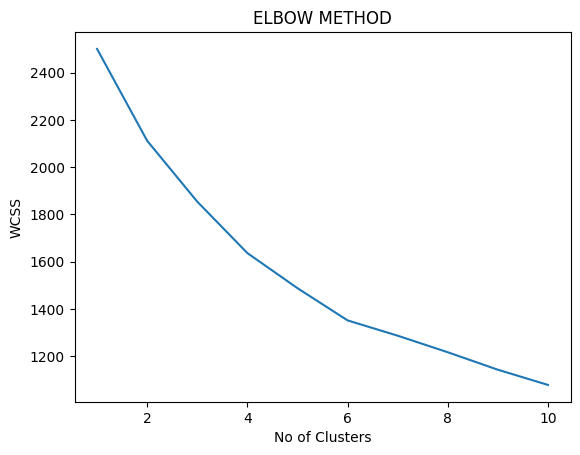

In [41]:
plt.plot(range(1,11),wcss)
plt.title('ELBOW METHOD')
plt.xlabel('No of Clusters')
plt.ylabel('WCSS')
plt.show()

## The End!!!

### Task:
* Silhoutee Score
* calinski harabasz score
* IRIS Dataset - apply this clustering techniques and check

### 1. Silhoutee Score


The Silhouette Score asks:

"How well does each data point belong to its own cluster compared with other clusters?"

For every data point, we calculate two things.

Step 1: Calculate a

a means:

How close am I to the members of my own cluster?

Example:

Cluster A:

A1 ---- A2 ---- A3

If A1 is close to A2 and A3, then a is small.

Small a = good because members of the same cluster are close.

Step 2: Calculate b

b means:

How far am I from the nearest different cluster?

Example:

Cluster A              Cluster B

● ● ● ●                     ▲ ▲ ▲ ▲

If the two clusters are far apart, b is large.

Large b = good because different clusters are separated.

4. Silhouette Score formula
$$ \text{Silhouette Score} = \frac{b-a}{\max(a,b)} $$

Where:

a = average distance to points in the same cluster
b = average distance to points in the nearest other cluster
Example

Suppose:

a = 2
b = 8

Then:

$$ \frac{8-2}{8} = \frac{6}{8} = 0.75 $$

So the Silhouette Score is:

$$ \boxed{0.75} $$

This is a good score. 🎉

Why?

My own cluster is close: a = 2
The other cluster is far: b = 8
5. How to understand Silhouette Score values

The score is between -1 and +1.

Score	Meaning
Close to +1	Excellent clustering 🟢
Around 0	Clusters are overlapping 🟡
Below 0	Data point may be in the wrong cluster 🔴
Visual example
Excellent
● ● ● ●          ▲ ▲ ▲ ▲

Own cluster       Other cluster
   CLOSE              FAR

Score might be: 0.8

Poor
● ● ▲ ● ▲ ● ▲

Score might be: 0.1

Wrong assignment
● ● ● ▲ ● ●

A point may receive a negative score.

In [42]:

from sklearn.metrics import silhouette_score

# Create K-Means model
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit and predict clusters
labels = kmeans.fit_predict(scaled_X)

# Calculate Silhouette Score
score = silhouette_score(scaled_X, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.1471449291589977


### 2. Calinski–Harabasz Score

Now let us learn the second score.

The Calinski–Harabasz Score asks:

"Are the clusters tight inside and far away from each other?"

This is very similar to a classroom example.

Imagine three groups of students standing in a playground.

Good grouping
Group 1          Group 2          Group 3

● ● ●             ▲ ▲ ▲            ■ ■ ■
● ● ●             ▲ ▲ ▲            ■ ■ ■

Each group is:

Compact (students are close)
Separated from other groups

This gives a high Calinski–Harabasz Score.

Bad grouping
● ▲ ■ ● ▲
■ ● ▲ ■ ●
▲ ■ ● ▲ ■

Everything is mixed.

This gives a low score.

8. Simple understanding of the formula

The actual formula is:

$$ CH = \frac{Between\ Cluster\ Separation} {Within\ Cluster\ Compactness} \times \frac{N-K}{K-1} $$

Where:

N = Total number of data points
K = Number of clusters

Don't worry too much about the formula. 😊

The important idea is:

Numerator: Between-cluster separation

How far are different clusters from each other?

Example:

Cluster A  ←──────── FAR ────────→ Cluster B

More separation = good.

Denominator: Within-cluster compactness

How close are members inside the same cluster?

Example:

● ● ●
● ● ●
● ● ●

More compactness = good.

Therefore:

$$ \boxed{\text{High Calinski-Harabasz Score = Better Clustering}} $$

In [44]:
from sklearn.metrics import calinski_harabasz_score

# Create K-Means model
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit and predict clusters
labels = kmeans.fit_predict(scaled_X)

# Calculate score
score = calinski_harabasz_score(scaled_X, labels)

print("Calinski-Harabasz Score:", score)

Calinski-Harabasz Score: 85.57217593004529


### Important difference between the two scores
| Feature                     | Silhouette Score                 | Calinski–Harabasz Score            |
| --------------------------- | -------------------------------- | ---------------------------------- |
| Checks                      | Cluster closeness and separation | Cluster compactness and separation |
| Best value                  | **Close to 1**                   | **Higher is better**               |
| Range                       | **-1 to +1**                     | No fixed upper limit               |
| Easy to interpret           | Yes                              | Less direct                        |
| Compares different K values | Yes                              | Yes                                |
| Higher is better?           | Yes                              | Yes                                |


### The biggest difference

Suppose you test different numbers of clusters.

|  K | Silhouette Score | CH Score |
| -: | ---------------: | -------: |
|  2 |             0.45 |      250 |
|  3 |         **0.72** |  **850** |
|  4 |             0.58 |      620 |
|  5 |             0.40 |      500 |



Best K = 3
Because:

Silhouette Score is highest for K = 3
CH Score is also highest for K = 3

So we can confidently choose: n_clusters = 3

## Finding the best number of clusters automatically

This is very useful in real machine-learning projects.

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,calinski_harabasz_score

for k in range(2, 8):

    # Create K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    # Predict clusters
    labels = kmeans.fit_predict(scaled_X)

    # Calculate scores
    sil_score = silhouette_score(scaled_X, labels)
    ch_score = calinski_harabasz_score(scaled_X, labels)

    print("K =", k)
    print("Silhouette Score =", sil_score)
    print("CH Score =", ch_score)
    print("-" * 40)

K = 2
Silhouette Score = 0.14678165370292873
CH Score = 90.4496644536654
----------------------------------------
K = 3
Silhouette Score = 0.1471449291589977
CH Score = 85.57217593004529
----------------------------------------
K = 4
Silhouette Score = 0.16779333855581194
CH Score = 87.69876829531145
----------------------------------------
K = 5
Silhouette Score = 0.1716184789910336
CH Score = 84.78616560073682
----------------------------------------
K = 6
Silhouette Score = 0.17053913219590736
CH Score = 81.77359561784583
----------------------------------------
K = 7
Silhouette Score = 0.17493814383664916
CH Score = 80.12420058957144
----------------------------------------


### 3. Davies–Bouldin Score
1. What is Davies–Bouldin Score?

Imagine you created three groups of students:

Group 1           Group 2           Group 3

● ● ● ●            ▲ ▲ ▲ ▲           ■ ■ ■ ■
● ● ●              ▲ ▲ ▲             ■ ■ ■

A good clustering has:

Students close together inside their own group.
Different groups far away from each other.

The Davies–Bouldin Score checks both.

"Are the clusters compact inside and separated from each other?"

2. Good clustering vs bad clustering
Good clustering
Cluster A                 Cluster B

● ● ● ●                        ▲ ▲ ▲ ▲
● ● ●                          ▲ ▲ ▲

      FAR APART

Inside each cluster: points are close.
Between clusters: they are far apart.

➡️ Davies–Bouldin Score = Low = Good 🟢

Bad clustering
Cluster A and Cluster B

● ▲ ● ▲ ●
▲ ● ▲ ● ▲
● ▲ ● ▲ ●

The clusters are mixed together.

➡️ Davies–Bouldin Score = High = Bad 🔴

3. The most important rule
Davies–Bouldin Score
$$ \boxed{\text{Lower is Better}} $$

This is different from the previous two metrics:

Silhouette Score        → Higher is Better
Calinski-Harabasz Score → Higher is Better
Davies-Bouldin Score    → Lower is Better
4. Simple formula

For two clusters, we can think of it like:

$$ \text{DB Ratio} = \frac{\text{Cluster A Spread}+\text{Cluster B Spread}} {\text{Distance between A and B}} $$
Easy example

Suppose:

Cluster A spread = 2
Cluster B spread = 3
Distance between clusters = 20

Then:

$$ DB = \frac{2+3}{20} $$ $$ DB = \frac{5}{20}=0.25 $$

A small value like 0.25 is generally better than a larger value like 1.5.

Why?

Because:

Clusters are compact.
Clusters are far from each other.
5. Real-life example 🍎 🍌 🍇

Imagine sorting fruits.

Good sorting
Box 1          Box 2          Box 3

🍎 🍎 🍎       🍌 🍌 🍌       🍇 🍇 🍇

Each box contains similar fruits.

The groups are clearly different.

➡️ Low DB Score

Bad sorting
Box 1              Box 2

🍎 🍌 🍇          🍌 🍎 🍇
🍇 🍎             🍇 🍌

The fruits are mixed.

➡️ High DB Score

6. Python example
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score

# Create K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# Create cluster labels
labels = kmeans.fit_predict(X)

# Calculate Davies-Bouldin Score
db_score = davies_bouldin_score(X, labels)

print("Davies-Bouldin Score:", db_score)

Suppose the output is:

Davies-Bouldin Score: 0.35

This indicates relatively better clustering than, for example, a score of 1.50 on the same dataset and preprocessing.

7. Complete comparison: All 3 metrics

| Metric                      | What does it check?                                        | Best value              |
| --------------------------- | ---------------------------------------------------------- | ----------------------- |
| **Silhouette Score**        | Are points close to their own cluster and far from others? | **Higher, close to +1** |
| **Calinski–Harabasz Score** | Are clusters compact and well separated?                   | **Higher is better**    |
| **Davies–Bouldin Score**    | How much do clusters spread and overlap?                   | **Lower is better**     |


Or:

Silhouette High, Calinski High, Davies Low!

In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score

# Create K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# Create cluster labels
labels = kmeans.fit_predict(scaled_X)

# Calculate Davies-Bouldin Score
db_score = davies_bouldin_score(scaled_X, labels)

print("Davies-Bouldin Score:", db_score)

Davies-Bouldin Score: 1.9762367789774273


In [51]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

for k in range(2, 8):

    # Create K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    # Fit the model and get cluster labels
    labels = kmeans.fit_predict(scaled_X)

    # Calculate all three scores
    silhouette = silhouette_score(scaled_X, labels)

    calinski = calinski_harabasz_score(scaled_X, labels)

    davies = davies_bouldin_score(scaled_X, labels)

    # Print results
    print("K =", k)
    print("Silhouette Score =", silhouette)
    print("Calinski-Harabasz Score =", calinski)
    print("Davies-Bouldin Score =", davies)

    print("-" * 50)

K = 2
Silhouette Score = 0.14678165370292873
Calinski-Harabasz Score = 90.4496644536654
Davies-Bouldin Score = 2.291531176851326
--------------------------------------------------
K = 3
Silhouette Score = 0.1471449291589977
Calinski-Harabasz Score = 85.57217593004529
Davies-Bouldin Score = 1.9762367789774273
--------------------------------------------------
K = 4
Silhouette Score = 0.16779333855581194
Calinski-Harabasz Score = 87.69876829531145
Davies-Bouldin Score = 1.7037394337502283
--------------------------------------------------
K = 5
Silhouette Score = 0.1716184789910336
Calinski-Harabasz Score = 84.78616560073682
Davies-Bouldin Score = 1.5247732012610262
--------------------------------------------------
K = 6
Silhouette Score = 0.17053913219590736
Calinski-Harabasz Score = 81.77359561784583
Davies-Bouldin Score = 1.5055096569866695
--------------------------------------------------
K = 7
Silhouette Score = 0.17493814383664916
Calinski-Harabasz Score = 80.12420058957144
Davie